# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA INFERENCIAL**


Una vez visto la presentación ***Introducción a la estadística inferencial***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.


## **PRUEBA DE HIPÓTESIS**

La **prueba de hipótesis** es un procedimiento formal dentro de la estadística inferencial que se usa para aceptar o rechazar una afirmación sobre un parámetro poblacional. Se basa en comparar dos hipótesis opuestas: la nula ($H_0$) y la alternativa ($H_1$).

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas**, **Seaborn** y **Scipy** para usar datasets precargados y operaciones estadísticas sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [ ]:
# Importar librerías

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
# Importar dataset

df_tips = sns.load_dataset('tips')
df_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### **NIVEL DE SIGNIFICANCIA:**

Es el umbral de error que estamos dispuestos a aceptar. Comúnmente se utiliza **$\alpha = 0.01, 0.05, 0.1$** representando el 1%, 5%, y 10% de nivel de significancia correspondientemente.

* Si el **p-value < $\alpha$**: Rechazamos $H_0$ (Hay evidencia estadística).

* Si el **p-value > $\alpha$**: No podemos rechazar $H_0$ (No hay suficiente evidencia).

In [ ]:
# Importar módulo
from scipy import stats

**Caso práctico:** ¿Existe una diferencia significativa entre la propina que dan los fumadores vs. los no fumadores?

* $H_0$: La media de propinas es igual para ambos grupos.

* $H_1$: La media de propinas es distinta entre fumadores y no fumadores.

In [ ]:
# Separaración de grupos

propinas_fumadores = df_tips[df_tips['smoker'] == 'Yes']['tip']
propinas_no_fumadores = df_tips[df_tips['smoker'] == 'No']['tip']

In [ ]:
df_tips[df_tips['smoker'] == 'Yes']['tip']

,tip
56,3.00
58,1.76
60,3.21
61,2.00
62,1.98
...,...
234,3.00
236,1.00
237,1.17
240,2.00


In [ ]:
df_tips[df_tips['smoker'] == 'No']['tip']

,tip
0,1.01
1,1.66
2,3.50
3,3.31
4,3.61
...,...
235,1.25
238,4.67
239,5.92
242,1.75


In [ ]:
# Aplicar Prueba T de Student

t_stats, p_value = stats.ttest_ind(propinas_fumadores, propinas_no_fumadores)

print(f'Estadístico T: {round(t_stats, 4)}')
print(f"P-Value: {p_value:.4f}")

Estadístico T: 0.0922
P-Value: 0.9266


In [ ]:
# Interpretar resultados

if p_value < 0.01:
  print("\nConclusión: Rechazamos la Hipótesis Nula.")
  print("Existe una diferencia muy significativa entre las propinas de ambos grupos.")

elif p_value >= 0.01 and p_value < 0.05:
  print("\nConclusión: Rechazamos la Hipótesis Nula.")
  print("Existe una diferencia altamente significativa entre las propinas de ambos grupos.")

elif p_value >= 0.05 and p_value < 0.10:
  print("\nConclusión: Rechazamos la Hipótesis Nula.")
  print("Existe una diferencia moderadamente significativa entre las propinas de ambos grupos.")

else:
  print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
  print("No hay evidencia suficiente para decir que las propinas son diferentes entre ambos grupos.")


Conclusión: No podemos rechazar la Hipótesis Nula.
No hay evidencia suficiente para decir que las propinas son diferentes entre ambos grupos.


## **APRENDIZAJE ESTADÍSTICO**

El **aprendizaje estadístico** es un marco de trabajo que **combina la estadística y la computación** para construir **modelos predictivos o de clasificación** a partir de los datos. Es la base teórica de lo que hoy conocemos como Machine Learning.

### **REGRESIÓN LINEAL SIMPLE:**



Una **regresión lineal simple** es un método estadístico utilizado para modelar la relación entre una variable independiente, el cual actua como una **variable predictora**, y una variable dependiente que actua como una **variable objetivo**.

Su objetivo es encontrar una línea recta que mejor se ajuste a los datos para **predecir un valor objetivo en función del valor predictor**.

Una regresión lineal tiene la forma:

\begin{equation} \overline{y} = β\overline{x} + α  \, \, \, \equiv \, \, \, y = mx + b \end{equation}

Y su función de costo:

\begin{equation} c(x) = \frac{1}{n} Σ_{i=1}^n(\overline{y} - y_i)² \end{equation}

In [ ]:
# Definir variables

x = df_tips['total_bill']
y = df_tips['tip']
n = len(x)

In [ ]:
# Definir regresión lineal

beta, alpha = np.polyfit(x, y, 1)
print(f'y = {round(beta, 2)}x + {round(alpha, 2)}')

y = 0.11x + 0.92


In [ ]:
# Predicción de valores con regresión lineal

cuenta_regresion = float(input('Ingresa el total de cuenta: '))
propina_regresion = round(beta * cuenta_regresion + alpha, 2)

print(f'La propina será de {propina_regresion}')

Ingresa el total de cuenta: 100
La propina será de 11.42


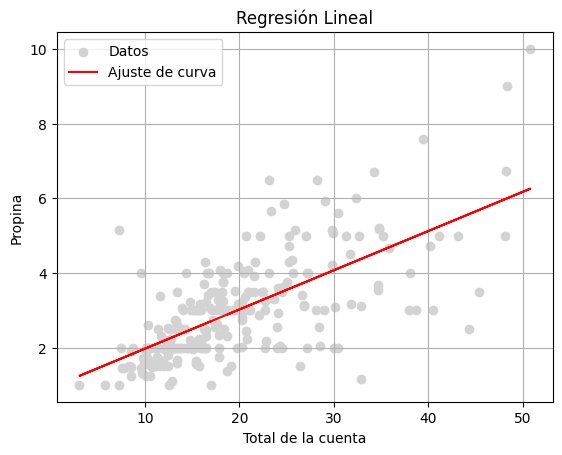

In [ ]:
# Visualizar regresión lineal

plt.scatter(x, y, color = 'lightgray', label = 'Datos')
plt.plot(x, beta*x + alpha, color = 'red', label = 'Ajuste de curva')
plt.title('Regresión Lineal')
plt.xlabel('Total de la cuenta')
plt.ylabel('Propina')
plt.legend(loc = 'upper left')
plt.grid()
plt.show()

In [ ]:
# Iterar pérdida de la regresión lineal

regresion_lineal = beta, alpha
iteraciones = 100
perdida = []

for i in range(iteraciones):

  y_prediccion = np.polyval(regresion_lineal, x)
  error = ((y_prediccion - y) ** 2).mean()
  perdida.append(error)

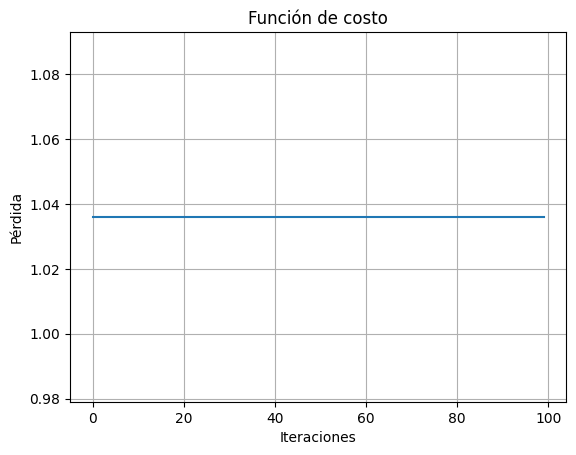

In [ ]:
# Visualizar pérdida de la regresión lineal

plt.plot(perdida, label = 'Errores')
plt.title('Función de costo')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.grid()
plt.show()

### **DESCENSO DE GRADIENTE:**

El **descenso de gradiente** es un algoritmo de optimización ampliamente utilizado en el campo del aprendizaje automático y en la resolución numérica de problemas de optimización.

Su objetivo principal es encontrar el **mínimo de una función**, lo que es esencial en la optimización de modelos y la resolución de problemas matemáticos, para ajustar los parámetros de manera que la **función de costo se minimice**.

El descenso de gradiente tiene la forma:

\begin{equation} (ϴ_0, ϴ_1)_{i+1} = (ϴ_0, ϴ_1)_i - α * \frac{∂\,\,c(ϴ_0, ϴ_1)}{∂(ϴ_0, ϴ_1)} \, \, \,\, \, \,\, \, \, ; \, \, \,\, \, \,\, \, \, α \in (0, 1) \end{equation}

Donde su predicción:

\begin{equation} h_ϴ(x) = ϴ_1x + ϴ_0  \, \, \, \equiv \, \, \, y = mx + b \end{equation}


In [ ]:
# Definir parámetros

tamaño_paso = 0.001
theta_0 = 0
theta_1 = 0

La función de costo tiene la forma:

\begin{equation} c(ϴ_0, ϴ_1) = \frac{1}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)² \end{equation}

Al derivar función de costo:

*   Parámetro 1:

\begin{equation} \frac{∂}{∂(ϴ_0)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i) \end{equation}


*   Paramétro 2:

\begin{equation} \frac{∂}{∂(ϴ_1)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)(x_i) \end{equation}

In [ ]:
# Realizar algoritmo del descenso de gradiente

iteraciones = 100
perdida = []

for i in range(iteraciones):

  y_prediccion = theta_1*x + theta_0
  error = ((y_prediccion - y) ** 2).mean()
  perdida.append(error)

  d_theta_0 = 2*(y_prediccion - y).mean()
  d_theta_1 = 2*((y_prediccion - y) * x).mean()

  theta_0 = theta_0 - tamaño_paso * d_theta_0
  theta_1 = theta_1 - tamaño_paso * d_theta_1

print(f'y = {round(theta_1, 2)}x + {round(theta_0, 2)}')

y = 0.14x + 0.04


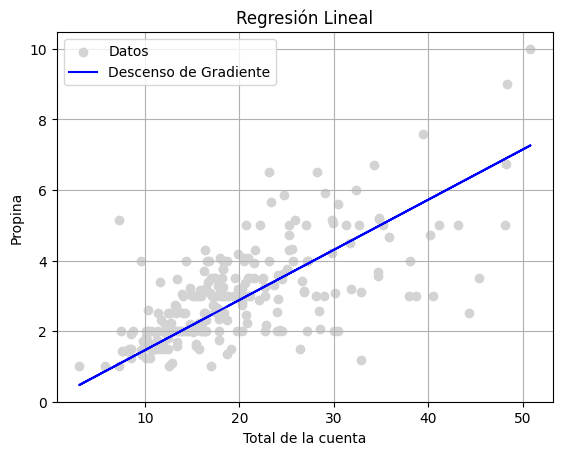

In [ ]:
# Visualizar la regresión lineal por descenso de gradiente

plt.scatter(x, y, color = 'lightgray', label = 'Datos')
plt.plot(x, theta_1*x + theta_0, color = 'blue', label = 'Descenso de Gradiente')
plt.title('Regresión Lineal')
plt.xlabel('Total de la cuenta')
plt.ylabel('Propina')
plt.legend(loc = 'upper left')
plt.grid()
plt.show()

In [ ]:
# Predicción de valores con descenso de gradiente

cuenta_gradiente = float(input('Ingresa el total de cuenta: '))
propina_gradiente = round(theta_1 * cuenta_gradiente + theta_0, 2)

print(f'La propina será de {propina_gradiente}')

Ingresa el total de cuenta: 100
La propina será de 14.26


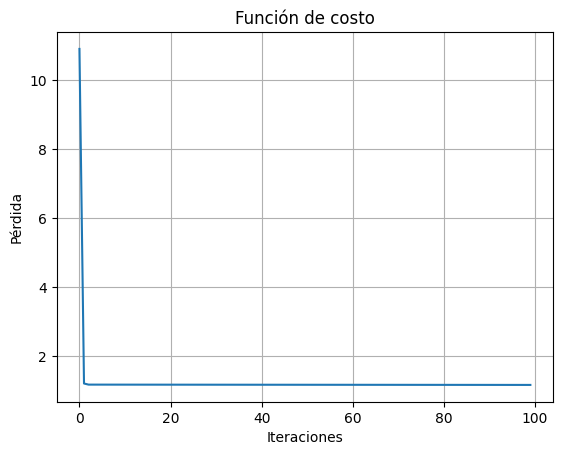

In [ ]:
# Visualizar las pérdidas

plt.plot(perdida, label = 'Errores')
plt.title('Función de costo')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.grid()
plt.show()

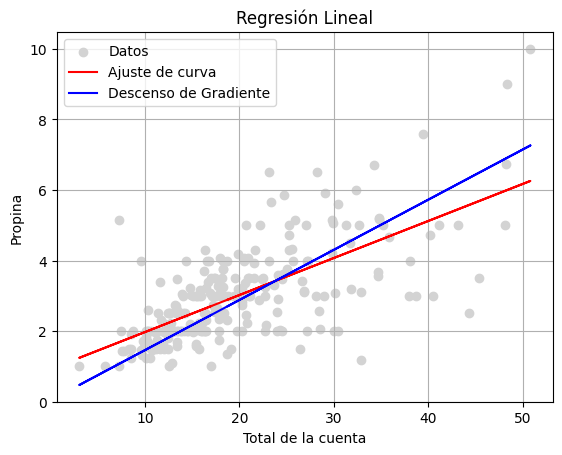

In [ ]:
# Comparar las rectas obtenidas por los algoritmos

plt.scatter(x, y, color = 'lightgray', label = 'Datos')
plt.plot(x, beta*x + alpha, color = 'red', label = 'Ajuste de curva')
plt.plot(x, theta_1*x + theta_0, color = 'blue', label = 'Descenso de Gradiente')
plt.title('Regresión Lineal')
plt.xlabel('Total de la cuenta')
plt.ylabel('Propina')
plt.legend(loc = 'upper left')
plt.grid()
plt.show()

## **CHALLENGE: ANÁLISIS PREDICTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística inferencial***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística inferecial** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Prueba de hipótesis**
*   **Aprendizaje estadístico**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [ ]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [ ]:
# Importar dataset
df_taxis = sns.load_dataset('taxis')
df_taxis
#df_taxis['color'].unique()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


**3. Realiza una prueba de hipótesis:** Determina si existe una diferencia significativa entre la distancia recorrida de los taxis color amarillo y verde.

Donde:

   * H0: La media de distancia es igual para ambos colores.
   * H1: La media de distancia es distinta entre colores.

In [ ]:
# Importar módulo
from scipy import stats

In [ ]:
# Separación de grupos
taxi_amarillo = df_taxis[df_taxis['color'] == 'yellow']['distance']
taxi_verde = df_taxis[df_taxis['color'] == 'green']['distance']

In [ ]:
# Aplicar Prueba T de Student

t_stats_color, p_value_color = stats.ttest_ind(taxi_amarillo, taxi_verde)

print(f"P-Value: {p_value_color:.4f}")

P-Value: 0.0007


In [ ]:
# Interpretación automática
if p_value_color < 0.01:
  print("\nConclusión: Rechazamos la Hipótesis Nula.")
  print("Existe una diferencia muy significativa entre la medida de distancia para ambos colores.")

elif 0.01 <= p_value_color < 0.05:
  # 0.01 <= p_value_color < 0.05
  print("\nConclusión: Rechazamos la Hipótesis Nula.")
  print("Existe una diferencia altamente significativa entre la medida de distancia para ambos colores.")

elif 0.05 <= p_value_color < 0.10:
  print("\nConclusión: Rechazamos la Hipótesis Nula.")
  print("Existe una diferencia moderadamente significativa entre la medida de distancia para ambos colores.")

else:
  print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
  print("No hay evidencia suficiente para decir que la medida de distancia es diferente para ambos colores.")


Conclusión: Rechazamos la Hipótesis Nula.
Existe una diferencia muy significativa entre la medida de distancia para ambos colores.


**4. Realiza un aprendizaje estadístico:**

   * Crea un modelo de regresión lineal simple para predecir el costo del viaje en función de la distancia recorrida.
   * Ajusta el modelo a través del algoritmo de optimización del descenso de gradiente.
   * Utiliza el modelo ajustado para realizar una predicción de cuánto costará un viaje de dado un valor agregado por el usuario en unidades de distancia.

In [ ]:
# Definir variables

x_distancia = df_taxis['distance']
y_costo = df_taxis['total']
n = len(x)

In [ ]:
# Definir regresión lineal
beta_, alpha_ = np.polyfit(x_distancia, y_costo, 1)
print(f'y = {round(beta_, 2)}x + {round(alpha_, 2)}')

y = 3.27x + 8.64


In [ ]:
# Definir Parámetros
tamaño_paso_taxis = 0.031 #prueba
theta_0_ = 0
theta_1_ = 0

# Realizar algoritmo del descenso de gradiente
iteraciones = 100
perdida = []

for i in range(iteraciones):

  y_prediccion = theta_1_ * x_distancia + theta_0_
  error = ((y_prediccion - y_costo) ** 2).mean()
  perdida.append(error)

  d_theta_0_ = 2*(y_prediccion - y_costo).mean()
  d_theta_1_ = 2*((y_prediccion - y_costo) * x_distancia).mean()

  theta_0_ = theta_0_ - tamaño_paso_taxis * d_theta_0_
  theta_1_ = theta_1_ - tamaño_paso_taxis * d_theta_1_

print(f'y = {round(theta_1_, 2)}x + {round(theta_0_, 2)}')

y = 3.29x + 8.47


In [ ]:
# Predicción de valores con descenso de gradiente
distancia_gradiente = float(input('Ingresa el total de distancia: '))
costo_gradiente = round(theta_1_ * distancia_gradiente + theta_0_, 2)

print(f'El costo del viaje será de {costo_gradiente}')

Ingresa el total de distancia: 4
El costo del viaje será de 21.62


**5. Visualiza los resultados:**

   * Grafica las líneas de las regresiones para comparar entre la regresión lineal simple y el algoritmo de optimización.
   * Grafica la función de costo resultante del ajuste con el algoritmo de optimización.

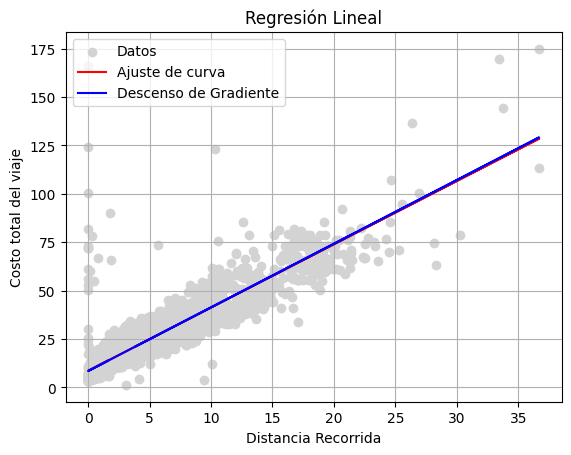

In [ ]:
# Visualizar regresiones
plt.scatter(x_distancia, y_costo, color = 'lightgray', label = 'Datos')
plt.plot(x_distancia, beta_*x_distancia + alpha_, color = 'red', label = 'Ajuste de curva')
plt.plot(x_distancia, theta_1_*x_distancia + theta_0_, color = 'blue', label = 'Descenso de Gradiente')
plt.title('Regresión Lineal')
plt.xlabel('Distancia Recorrida')
plt.ylabel('Costo total del viaje')
plt.legend(loc = 'upper left')
plt.grid()
plt.show()

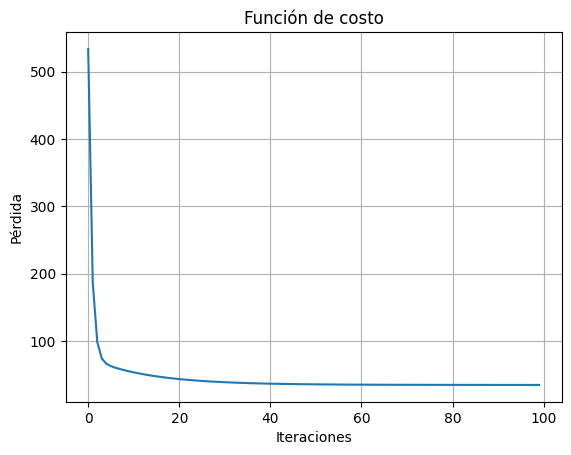

In [ ]:
# Visualizar función de costo
plt.plot(perdida, label = 'Errores')
plt.title('Función de costo')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.grid()
plt.show()